In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = ["#4C72B0", "#55A868", "#DD8452", "#C44E52", "#9467BD"]
print("Imports complete.")


Imports complete.


In [ ]:
path = "/content/drive/MyDrive/MS2 ML Project/"
save_dir = "/content/drive/MyDrive/MS2 ML Project/saved_objects/"
os.makedirs(save_dir, exist_ok=True)

print("Save directory:", save_dir)

assessments = pd.read_csv(path + "assessments.csv")
courses = pd.read_csv(path + "courses.csv")
studentAssessment = pd.read_csv(path + "StudentAssesments.csv")
studentInfo = pd.read_csv(path + "studentInfo.csv")
studentRegistration = pd.read_csv(path + "studentRegistration.csv")
studentVle = pd.read_csv(path + "studentVle.csv")
vle = pd.read_csv(path + "vle.csv")

Save directory: /content/drive/MyDrive/MS2 ML Project/saved_objects/


# 1) Preprocessing:

In [ ]:
print(assessments.shape)
print(courses.shape)
print(studentAssessment.shape)
print(studentInfo.shape)
print(studentRegistration.shape)
print(studentVle.shape)
print(vle.shape)
studentVle.head()

(206, 6)
(22, 3)
(163912, 5)
(32593, 11)
(32593, 5)
(10655280, 6)
(6364, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [ ]:
studentVle_full = studentVle.merge( vle,  on=["id_site", "code_module", "code_presentation"] )
studentVle_agg = studentVle_full.groupby(["code_module", "code_presentation", "id_student"]
).agg(
    total_clicks=("sum_click", "sum"),
    avg_clicks=("sum_click", "mean"),
    interaction_days=("date", "nunique"),
    total_interactions=("id_site", "count"),
    unique_activity_types=("activity_type", "nunique")
).reset_index()

In [ ]:
df = studentAssessment.merge(assessments, on="id_assessment", how="left")
df = df.merge( studentInfo,on=["id_student", "code_module", "code_presentation"], how="left")
df = df.merge( courses,on=["code_module", "code_presentation"],how="left")
df = df.merge(studentRegistration,on=["id_student", "code_module", "code_presentation"],how="left")
df = df.merge(studentVle_agg,on=["id_student", "code_module", "code_presentation"],how="left")

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(df.info())

(163912, 26)
id_assessment                   0
id_student                      0
date_submitted                  0
is_banked                       0
assessmentClass                 0
code_module                     0
code_presentation               0
assessment_type                 0
date                            0
weight                          0
gender                          0
region                          0
highest_education               0
imd_band                        0
age_band                        0
num_of_prev_attempts            0
studied_credits                 0
disability                      0
module_presentation_length      0
date_registration               0
date_unregistration             0
total_clicks                  158
avg_clicks                    158
interaction_days              158
total_interactions            158
unique_activity_types         158
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163912 entries, 0 to 163911
Data columns

In [ ]:
for col in df.select_dtypes(include='object').columns:
    weird_values = df[col][~df[col].astype(str).str.match(r'^[a-zA-Z0-9\s\-\.%]+$')]

    if not weird_values.empty:
        print(f"\nWeird values in column: {col}")
        print(weird_values.unique()[:10])


Weird values in column: date
['?']

Weird values in column: imd_band
['?']

Weird values in column: age_band
['55<=']

Weird values in column: date_registration
['?']

Weird values in column: date_unregistration
['?']


In [ ]:
df.replace("?", np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
assessmentClass,0
code_module,0
code_presentation,0
assessment_type,0
date,2709
weight,0


In [ ]:
df['has_unregistered'] = df['date_unregistration'].notna().astype(int)
df.drop(columns=['id_assessment', 'id_student', 'date_unregistration'], inplace=True)

df["date"] = pd.to_numeric(df["date"], errors="coerce")
df["date_registration"] = pd.to_numeric(df["date_registration"], errors="coerce")

df["date"].fillna(df["date"].median(), inplace=True)
df["date_registration"].fillna(df["date_registration"].median(), inplace=True)

df["imd_band"].fillna("Unknown", inplace=True)

vle_cols = ["total_clicks", "avg_clicks", "interaction_days",
            "total_interactions", "unique_activity_types"]
df[vle_cols] = df[vle_cols].fillna(0)

le_target = LabelEncoder() # --> change to one hot encoding
df['assessmentClass'] = le_target.fit_transform(df['assessmentClass'])
print("Target classes:", le_target.classes_)

cat_cols = df.select_dtypes(include="object").columns.tolist()
df = pd.get_dummies(df, columns=cat_cols)

print("Nulls remaining:", df.isnull().sum().sum())   # should be 0
print("Shape:", df.shape)
print(df.head())

Target classes: ['Excellent' 'Fail' 'Good' 'Very Good']
Nulls remaining: 0
Shape: (163912, 65)
   date_submitted  is_banked  assessmentClass   date  weight  \
0              21          0                3   18.0     2.0   
1             235          0                2  241.0     0.0   
2             207          0                1  207.0    20.0   
3             116          0                1  116.0    15.0   
4             171          0                3  173.0     0.0   

   num_of_prev_attempts  studied_credits  module_presentation_length  \
0                     0               30                         269   
1                     0              120                         269   
2                     0               90                         261   
3                     0               60                         240   
4                     0               30                         261   

   date_registration  total_clicks  ...  imd_band_60-70%  imd_band_70-80%  \
0         

In [ ]:
print(df['assessmentClass'].value_counts())

assessmentClass
3    57623
0    41353
2    38636
1    26300
Name: count, dtype: int64


# 2) Data Analysis & Correlation

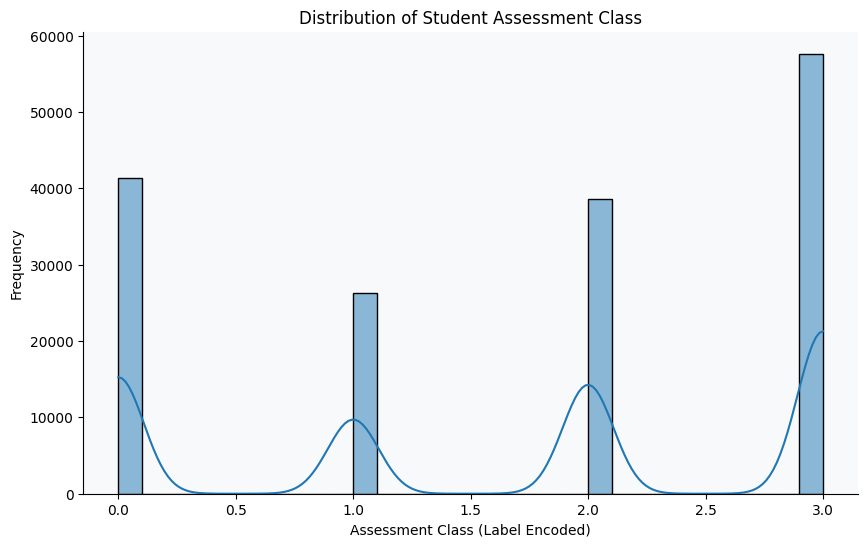

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['assessmentClass'], bins=30, kde=True)
plt.title('Distribution of Student Assessment Class')
plt.xlabel('Assessment Class (Label Encoded)')
plt.ylabel('Frequency')
plt.show()

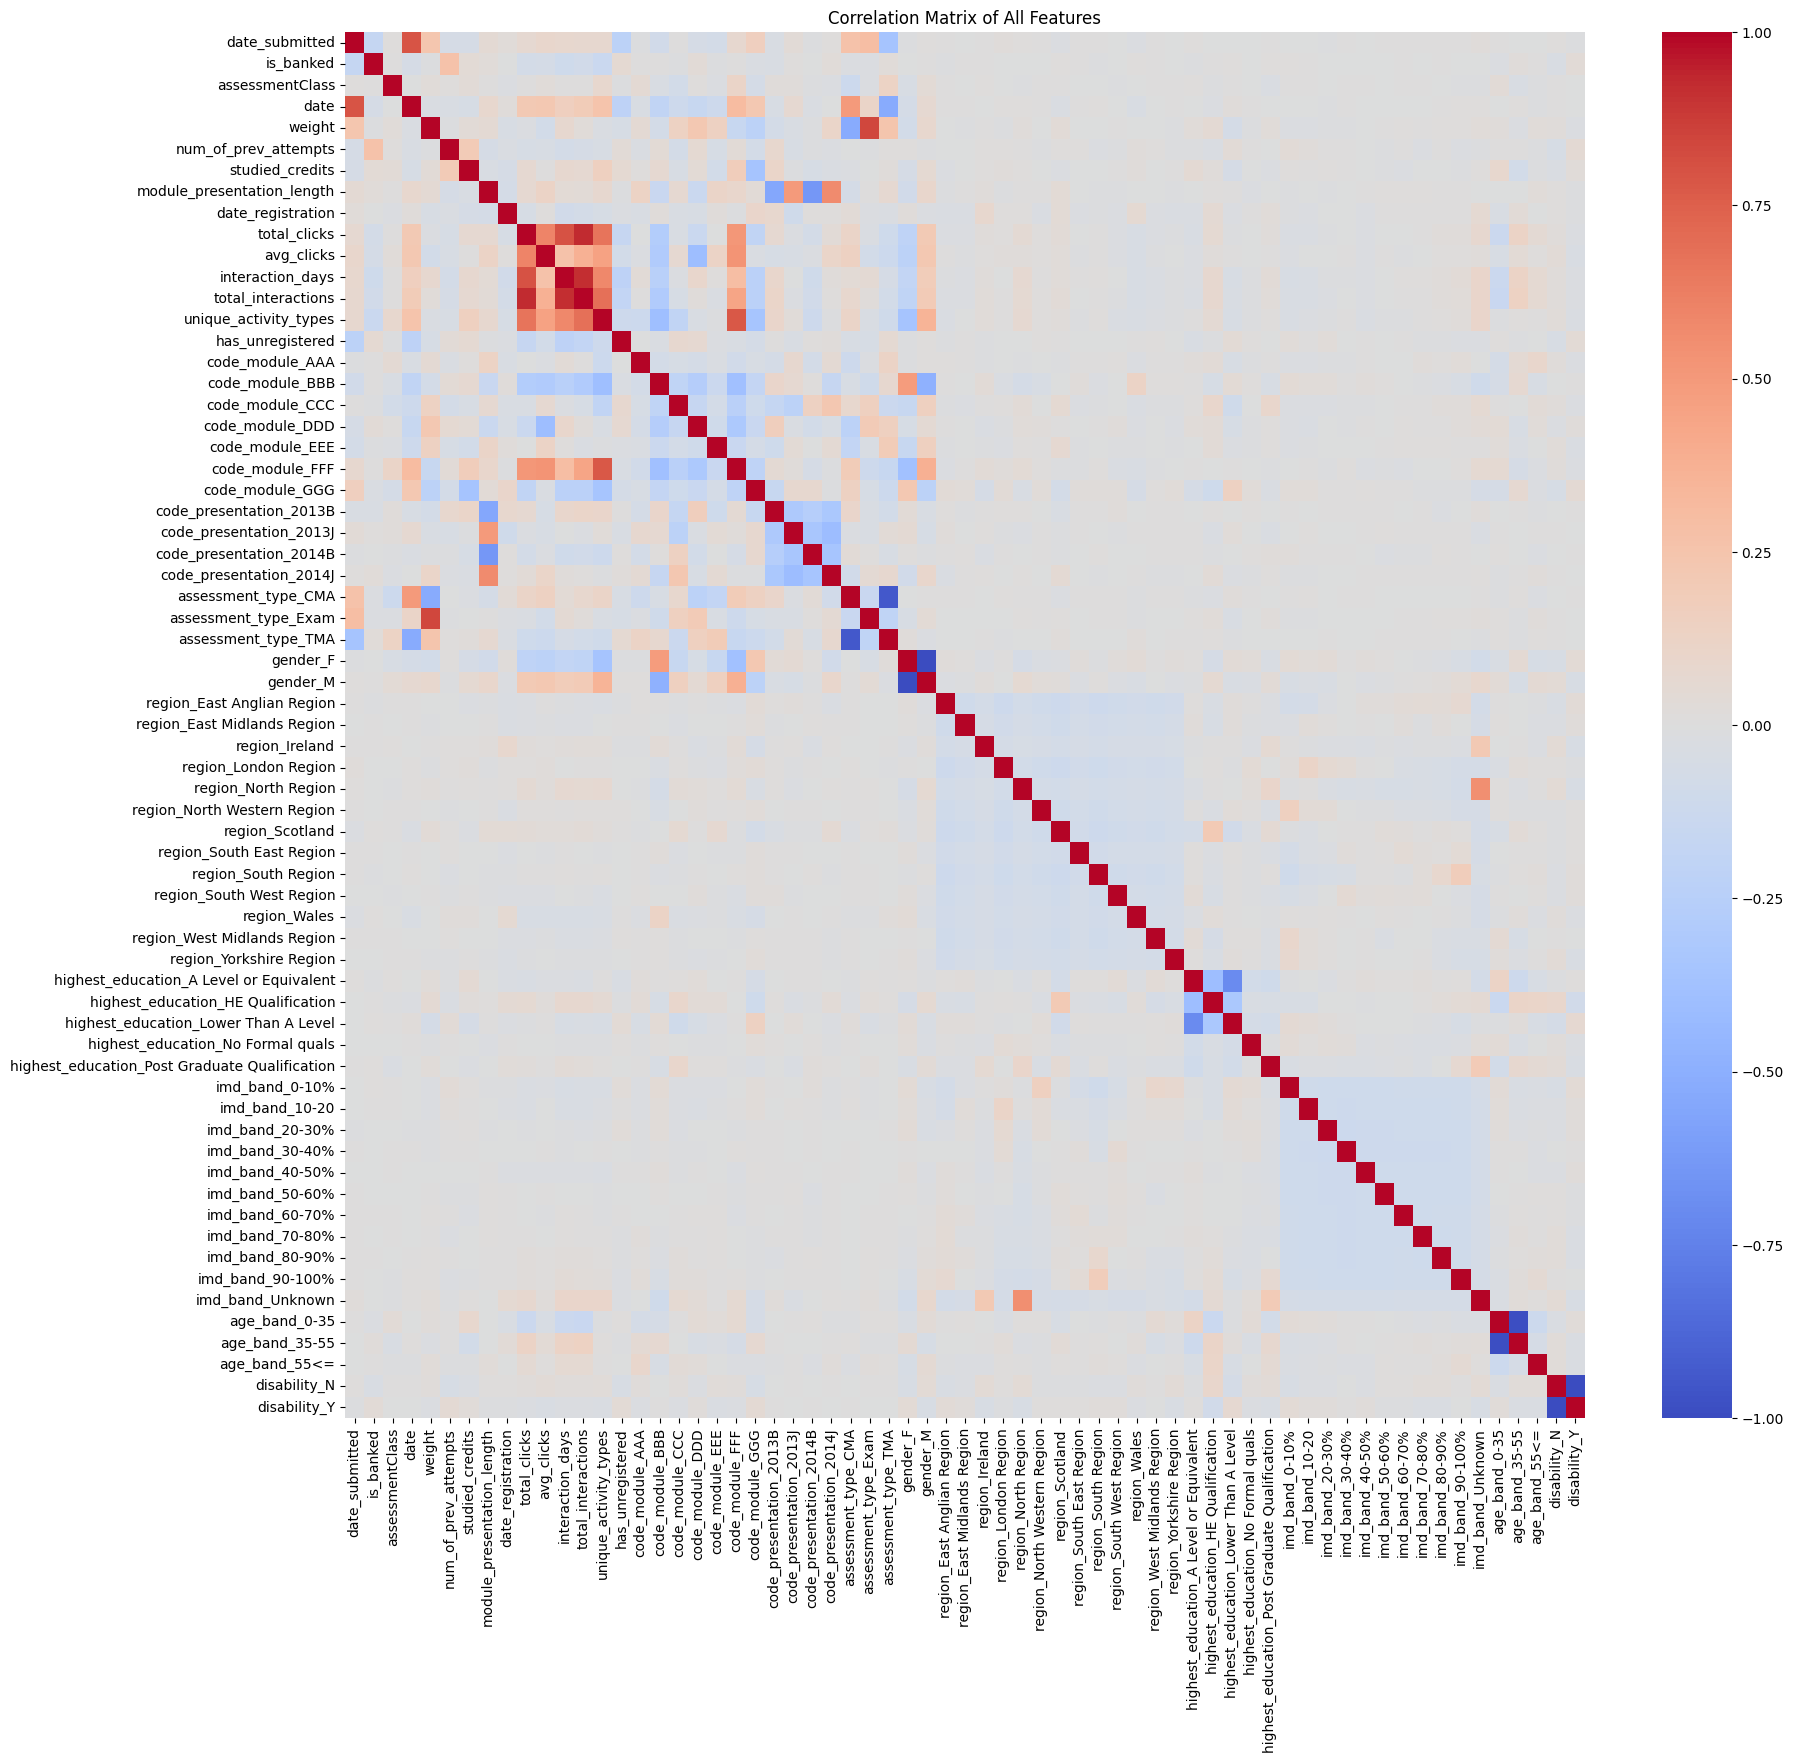

In [ ]:
correlation_matrix = df.corr()
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Features')
plt.show()

In [ ]:
target_correlation = correlation_matrix['assessmentClass'].sort_values(ascending=False)
print("Correlation with 'assessmentClass' (target variable):")
display(target_correlation)

Correlation with 'assessmentClass' (target variable):


,assessmentClass
assessmentClass,1.000000
assessment_type_TMA,0.128012
code_module_FFF,0.109722
unique_activity_types,0.085925
code_module_AAA,0.050525
...,...
age_band_35-55,-0.037388
gender_F,-0.041277
code_module_GGG,-0.063008
code_module_CCC,-0.078804


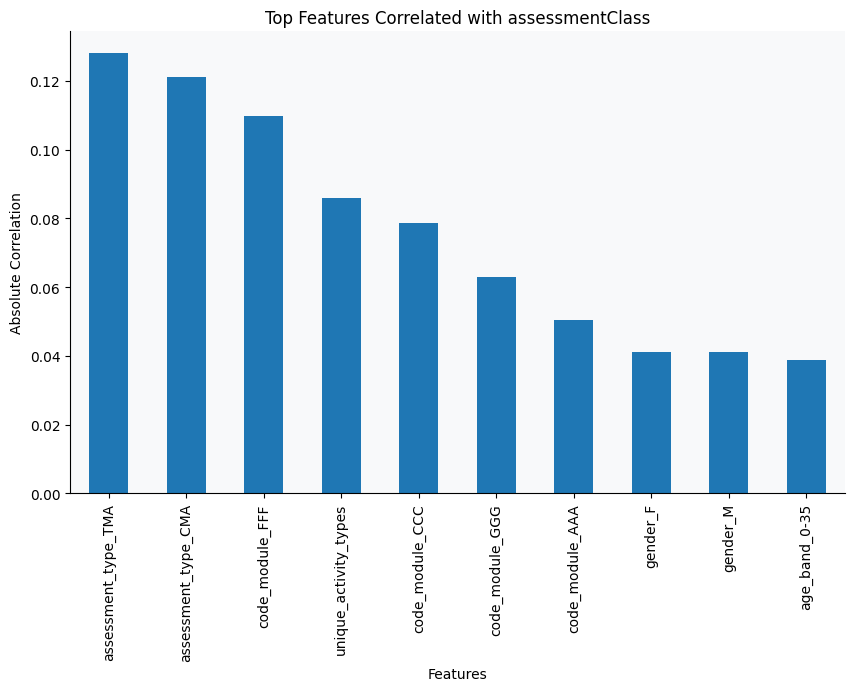

In [ ]:
top_corr = target_correlation.abs().sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,6))
top_corr.plot(kind='bar')

plt.title("Top Features Correlated with assessmentClass")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")

plt.show()

# 3) Feature Engineering

In [ ]:

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
print(df.shape)
print(df.info())
df.describe()

(163912, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163912 entries, 0 to 163911
Data columns (total 65 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   date_submitted                                 163912 non-null  int64  
 1   is_banked                                      163912 non-null  int64  
 2   assessmentClass                                163912 non-null  int64  
 3   date                                           163912 non-null  float64
 4   weight                                         163912 non-null  float64
 5   num_of_prev_attempts                           163912 non-null  int64  
 6   studied_credits                                163912 non-null  int64  
 7   module_presentation_length                     163912 non-null  int64  
 8   date_registration                              163912 non-null  float64
 9   total_clicks            

,date_submitted,is_banked,assessmentClass,date,weight,num_of_prev_attempts,studied_credits,module_presentation_length,date_registration,total_clicks,...,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_0-35,age_band_35-55,age_band_55<=,disability_N,disability_Y
count,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,...,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000,163912.000000
mean,116.001147,0.010853,1.686521,130.511537,12.761848,0.144675,76.765673,255.227567,-65.937595,1966.509621,...,0.092934,0.093727,0.090945,0.087169,0.044359,0.686069,0.307214,0.006717,0.912911,0.087089
std,71.475857,0.103613,1.192850,77.387846,17.914820,0.445018,37.358124,13.580416,47.008255,2028.684006,...,0.290341,0.291450,0.287532,0.282083,0.205892,0.464090,0.461340,0.081682,0.281967,0.281967
min,-11.000000,0.000000,0.000000,12.000000,0.000000,0.000000,30.000000,234.000000,-311.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,0.000000,0.000000,54.000000,0.000000,0.000000,60.000000,240.000000,-94.000000,585.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,116.000000,0.000000,2.000000,129.000000,10.000000,0.000000,60.000000,262.000000,-53.000000,1289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,173.000000,0.000000,3.000000,208.000000,18.000000,0.000000,90.000000,268.000000,-29.000000,2695.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000
max,608.000000,1.000000,3.000000,261.000000,100.000000,6.000000,630.000000,269.000000,167.000000,24139.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Correlation of engineered features with assessmentClass:

submitted_late                0.1240
low_engagement_late           0.1128
engaged_but_late              0.0373
click_per_day                 0.0364
avg_clicks_per_interaction    0.0268
activity_diversity_ratio      0.0244
high_credit_load              0.0194
is_heavy_engager              0.0186
registration_offset           0.0175
submission_offset             0.0157
submission_timing_ratio       0.0152
has_prior_attempts            0.0131
submitted_early               0.0057
engagement_ratio              0.0021
Name: assessmentClass, dtype: float64


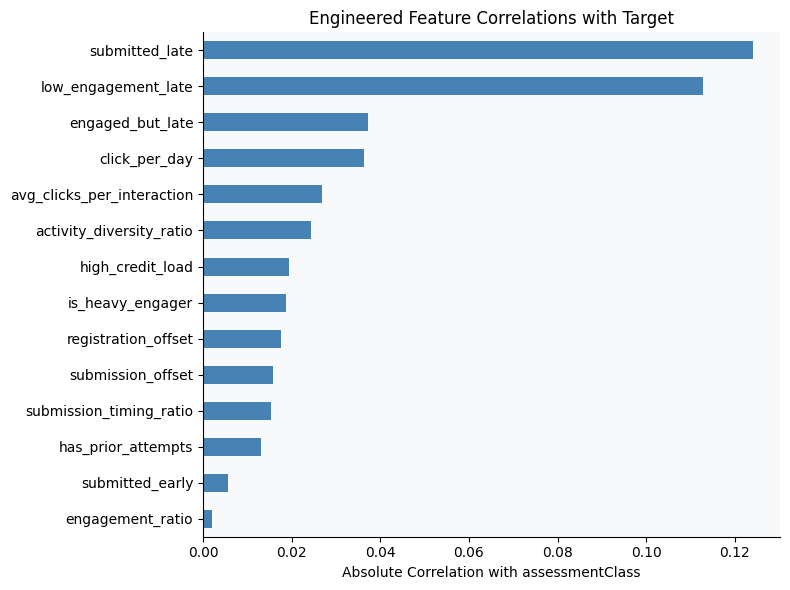

In [ ]:
# Submission 
df['submission_offset']       = df['date_submitted'] - df['date']
df['submitted_late']          = (df['submission_offset'] > 0).astype(int)
df['submitted_early']         = (df['submission_offset'] < -3).astype(int)
df['submission_timing_ratio'] = df['submission_offset'] / (df['module_presentation_length'] + 1)

# engagement
df['click_per_day']              = df['total_clicks'] / (df['interaction_days'] + 1)
df['avg_clicks_per_interaction'] = df['total_clicks'] / (df['total_interactions'] + 1)
df['activity_diversity_ratio']   = df['unique_activity_types'] / (df['total_interactions'] + 1)
df['engagement_ratio']           = (df['interaction_days'] / (df['module_presentation_length'] + 1)).clip(upper=1.0)

click_threshold      = df['total_clicks'].quantile(0.75)
df['is_heavy_engager'] = (df['total_clicks'] >= click_threshold).astype(int)

# student 
df['registration_offset'] = df['date_registration']
df['has_prior_attempts']  = (df['num_of_prev_attempts'] > 0).astype(int)
df['high_credit_load']    = (df['studied_credits'] > df['studied_credits'].median()).astype(int)


df['engaged_but_late']   = ((df['is_heavy_engager'] == 1) & (df['submitted_late'] == 1)).astype(int)
df['low_engagement_late']= ((df['is_heavy_engager'] == 0) & (df['submitted_late'] == 1)).astype(int)

df.drop(columns=['avg_clicks', 'total_interactions', 'interaction_days'], inplace=True)


new_features = [
    'submission_offset', 'submitted_late', 'submitted_early', 'submission_timing_ratio',
    'click_per_day', 'avg_clicks_per_interaction', 'activity_diversity_ratio',
    'engagement_ratio', 'is_heavy_engager', 'registration_offset',
    'has_prior_attempts', 'high_credit_load', 'engaged_but_late', 'low_engagement_late'
]

correlations = df[new_features + ['assessmentClass']].corr()['assessmentClass'].drop('assessmentClass')
correlations = correlations.abs().sort_values(ascending=False)

print("Correlation of engineered features with assessmentClass:\n")
print(correlations.round(4))

correlations.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Absolute Correlation with assessmentClass")
plt.title("Engineered Feature Correlations with Target")
plt.tight_layout()
plt.show()

In [ ]:
classification_preprocess_values = {
    "date_median": df["date"].median(),
    "date_registration_median": df["date_registration"].median(),
    "click_threshold": click_threshold,
    "studied_credits_median": df["studied_credits"].median()
}

with open(save_dir + "classification_preprocess_values.pkl", "wb") as f:
    pickle.dump(classification_preprocess_values, f)

print("Saved classification preprocessing values:")
print(classification_preprocess_values)

Saved classification preprocessing values:
{'date_median': 129.0, 'date_registration_median': -53.0, 'click_threshold': np.float64(2695.0), 'studied_credits_median': 60.0}


In [ ]:
feature_columns = df.drop("assessmentClass", axis=1).columns.tolist()

with open(save_dir + "classification_feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Saved classification feature columns:", len(feature_columns))

Saved classification feature columns: 75


# 4) Models

In [ ]:
import time
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
X = df.drop("assessmentClass", axis=1)
X = X.reindex(columns=feature_columns, fill_value=0)
y = df["assessmentClass"]
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
best_tracker = {
    'lr': {'model': None, 'train_acc': 0, 'test_acc': 0, 'train_time': 0, 'test_time': 0},
    'rf': {'model': None, 'train_acc': 0, 'test_acc': 0, 'train_time': 0, 'test_time': 0},
    'dt': {'model': None, 'train_acc': 0, 'test_acc': 0, 'train_time': 0, 'test_time': 0},
    'gb': {'model': None, 'train_acc': 0, 'test_acc': 0, 'train_time': 0, 'test_time': 0}
}
def evaluate_model(model_key, model, train_time, test_time):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    if test_acc > best_tracker[model_key]['test_acc']:
        best_tracker[model_key]['test_acc'] = test_acc
        best_tracker[model_key]['train_acc'] = train_acc
        best_tracker[model_key]['model'] = model
        best_tracker[model_key]['train_time'] = train_time
        best_tracker[model_key]['test_time'] = test_time
    return train_acc, test_acc

In [ ]:
print("\n── Logistic Regression ──")
#hyperparameter1
for c in [0.001, 1, 100]:
    start = time.time()
    model = LogisticRegression(C=c, solver='lbfgs', max_iter=1000 , class_weight='balanced').fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('lr', model, train_time, test_time)
    print(f"[C={c}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")
#hyperparameter2
for s in ['lbfgs', 'newton-cg', 'sag']:
    start = time.time()
    model = LogisticRegression(C=1.0, solver=s, max_iter=1000).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('lr', model, train_time, test_time)
    print(f"[Solver={s}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")


── Logistic Regression ──
[C=0.001] Train Acc: 0.4117 | Test Acc: 0.4111 | Train Time: 3.65s | Test Time: 0.0135s
[C=1] Train Acc: 0.4122 | Test Acc: 0.4098 | Train Time: 14.88s | Test Time: 0.0174s
[C=100] Train Acc: 0.4123 | Test Acc: 0.4098 | Train Time: 16.86s | Test Time: 0.0362s
[Solver=lbfgs] Train Acc: 0.4420 | Test Acc: 0.4418 | Train Time: 10.94s | Test Time: 0.0153s
[Solver=newton-cg] Train Acc: 0.4419 | Test Acc: 0.4420 | Train Time: 3.50s | Test Time: 0.0136s
[Solver=sag] Train Acc: 0.4419 | Test Acc: 0.4417 | Train Time: 11.54s | Test Time: 0.0137s


In [ ]:
print("\n── Random Forest (balanced) ──")
for n in [50, 100, 200]:
    start = time.time()
    model = RandomForestClassifier(
        n_estimators=n, max_depth=10,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time(); model.predict(X_test); test_time = time.time() - start
    tr, te = evaluate_model('rf', model, train_time, test_time)
    print(f"[n={n}] Train: {tr:.4f} | Test: {te:.4f} | Train time: {train_time:.2f}s")

for d in [5, 10, 20]:
    start = time.time()
    model = RandomForestClassifier(
        n_estimators=100, max_depth=d,
        class_weight='balanced',
        random_state=42, n_jobs=-1
    ).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time(); model.predict(X_test); test_time = time.time() - start
    tr, te = evaluate_model('rf', model, train_time, test_time)
    print(f"[depth={d}] Train: {tr:.4f} | Test: {te:.4f} | Train time: {train_time:.2f}s")


── Random Forest (balanced) ──
[n=50] Train: 0.4761 | Test: 0.4449 | Train time: 9.04s
[n=100] Train: 0.4775 | Test: 0.4459 | Train time: 15.95s
[n=200] Train: 0.4775 | Test: 0.4467 | Train time: 31.88s
[depth=5] Train: 0.4233 | Test: 0.4219 | Train time: 9.15s
[depth=10] Train: 0.4775 | Test: 0.4459 | Train time: 16.34s
[depth=20] Train: 0.9061 | Test: 0.5122 | Train time: 35.11s


In [ ]:
print("\n── Decision Tree ──")
#hyperparameter1
for s in [2, 5, 10]:
    start = time.time()
    model = DecisionTreeClassifier(max_depth=10, min_samples_split=s, random_state=42).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('dt', model, train_time, test_time)
    print(f"[split={s}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")
#hyperparameter2
for l in [1, 2, 4]:
    start = time.time()
    model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=l, random_state=42).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('dt', model, train_time, test_time)
    print(f"[leaf={l}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")


── Decision Tree ──
[split=2] Train Acc: 0.4863 | Test Acc: 0.4562 | Train Time: 2.08s | Test Time: 0.0091s
[split=5] Train Acc: 0.4861 | Test Acc: 0.4562 | Train Time: 2.07s | Test Time: 0.0091s
[split=10] Train Acc: 0.4856 | Test Acc: 0.4561 | Train Time: 2.08s | Test Time: 0.0090s
[leaf=1] Train Acc: 0.4863 | Test Acc: 0.4562 | Train Time: 2.83s | Test Time: 0.0123s
[leaf=2] Train Acc: 0.4859 | Test Acc: 0.4561 | Train Time: 2.56s | Test Time: 0.0093s
[leaf=4] Train Acc: 0.4852 | Test Acc: 0.4558 | Train Time: 2.08s | Test Time: 0.0091s


In [ ]:
print("\n── Gradient Boosting ──")
#hyperparameter1
for lr in [0.05, 0.1, 0.2]:
    start = time.time()
    model = GradientBoostingClassifier(learning_rate=lr, n_estimators=200, random_state=42).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('gb', model, train_time, test_time)
    print(f"[lr={lr}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")
#hyperparameter2
for n in [30, 50, 80]:
    start = time.time()
    model = GradientBoostingClassifier(learning_rate=0.2, n_estimators=n, random_state=42).fit(X_train, y_train)
    train_time = time.time() - start
    start = time.time()
    model.predict(X_test)
    test_time = time.time() - start
    train_acc, test_acc = evaluate_model('gb', model, train_time, test_time)
    print(f"[n={n}] Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | "
          f"Train Time: {train_time:.2f}s | Test Time: {test_time:.4f}s")


── Gradient Boosting ──
[lr=0.05] Train Acc: 0.4754 | Test Acc: 0.4737 | Train Time: 512.01s | Test Time: 0.5573s
[lr=0.1] Train Acc: 0.4860 | Test Acc: 0.4796 | Train Time: 500.56s | Test Time: 0.6442s
[lr=0.2] Train Acc: 0.5039 | Test Acc: 0.4833 | Train Time: 500.05s | Test Time: 0.4305s
[n=30] Train Acc: 0.4686 | Test Acc: 0.4687 | Train Time: 75.46s | Test Time: 0.0924s
[n=50] Train Acc: 0.4759 | Test Acc: 0.4734 | Train Time: 126.01s | Test Time: 0.1379s
[n=80] Train Acc: 0.4832 | Test Acc: 0.4766 | Train Time: 199.67s | Test Time: 0.2040s


In [ ]:
print("\n--- Saving Classification Models and Objects ---")

for key, data in best_tracker.items():
    with open(save_dir + f"{key}_model.pkl", "wb") as f:
        pickle.dump(data['model'], f)
    print(f"{key} saved | Best Test Acc: {data['test_acc']:.4f}")

with open(save_dir + "classification_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(save_dir + "target_le.pkl", "wb") as f:
    pickle.dump(le_target, f)

with open(save_dir + "classification_feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

with open(save_dir + "classification_preprocess_values.pkl", "wb") as f:
    pickle.dump(classification_preprocess_values, f)

print("\nDone saving classification models, scaler, target encoder, feature columns, and preprocessing values.")


--- Saving Classification Models and Objects ---
lr saved | Best Test Acc: 0.4420
rf saved | Best Test Acc: 0.5122
dt saved | Best Test Acc: 0.4562
gb saved | Best Test Acc: 0.4833

Done saving classification models, scaler, target encoder, feature columns, and preprocessing values.


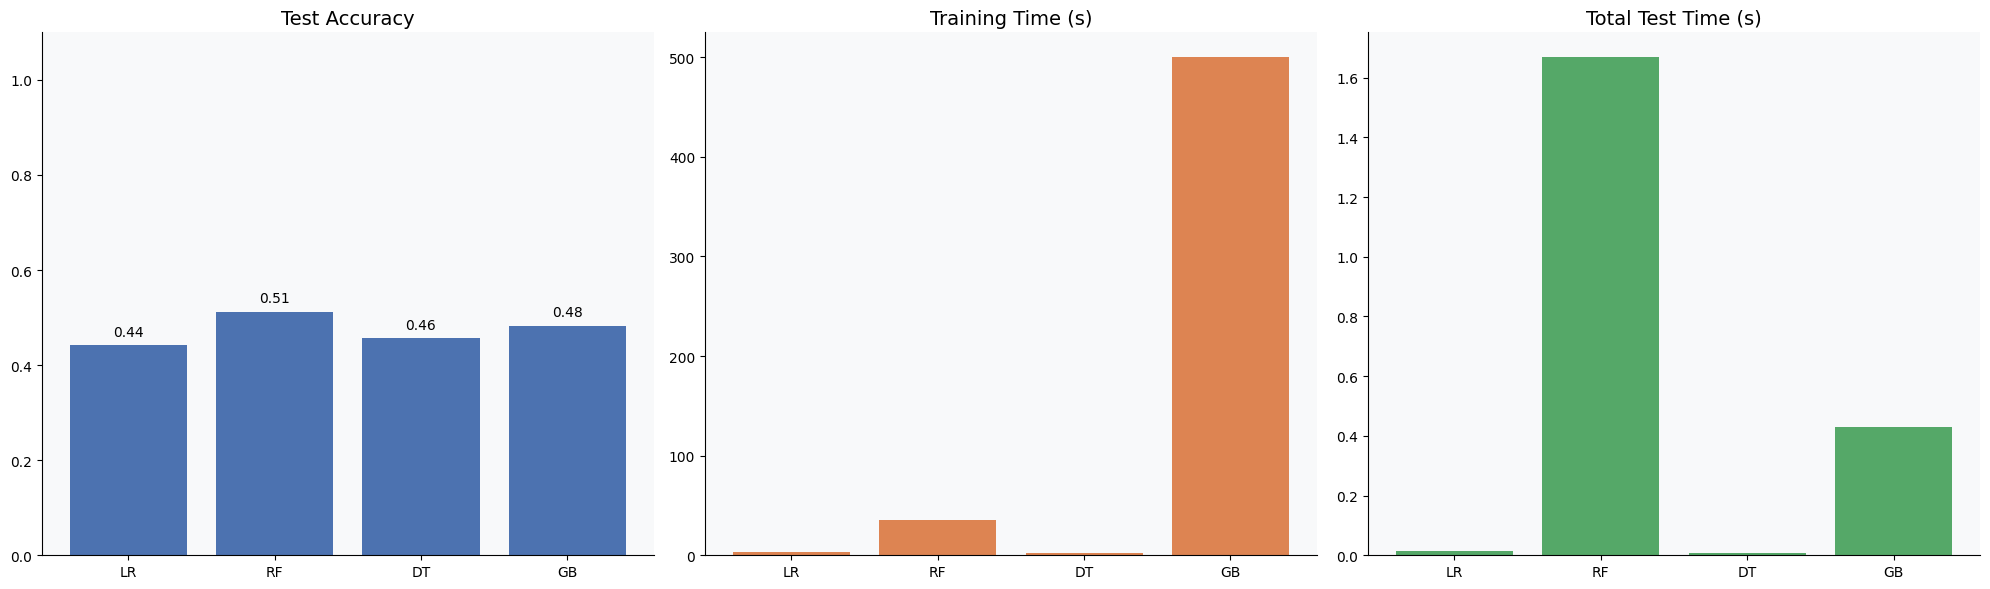

In [ ]:
models_names = [m.upper() for m in best_tracker.keys()]
accuracies = [best_tracker[m]['test_acc'] for m in best_tracker.keys()]
train_times = [best_tracker[m]['train_time'] for m in best_tracker.keys()]
test_times = [best_tracker[m]['test_time'] for m in best_tracker.keys()]
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
ax[0].bar(models_names, accuracies, color='#4C72B0')
ax[0].set_title('Test Accuracy', fontsize=14)
ax[0].set_ylim(0, 1.1)
for i, v in enumerate(accuracies):
    ax[0].text(i, v + 0.02, f"{v:.2f}", ha='center')
ax[1].bar(models_names, train_times, color='#DD8452')
ax[1].set_title('Training Time (s)', fontsize=14)
ax[2].bar(models_names, test_times, color='#55A868')
ax[2].set_title('Total Test Time (s)', fontsize=14)
plt.tight_layout()
plt.show()

# 5) Evaluation , Visualization & Report.


In [ ]:
import time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

warnings.filterwarnings('ignore')

save_dir = "/content/drive/MyDrive/MS2 ML Project/saved_objects/"

KEYS    = list(best_tracker.keys())
NAMES   = ['Logistic Reg', 'Random Forest', 'Dec. Tree', 'Grad. Boost']
COLORS  = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

CLASSES = le_target.classes_

pickle.dump(le_target, open(save_dir + 'target_le.pkl', 'wb'))

print('target_le.pkl saved')
print("Classes:", CLASSES)

target_le.pkl saved
Classes: ['Excellent' 'Fail' 'Good' 'Very Good']


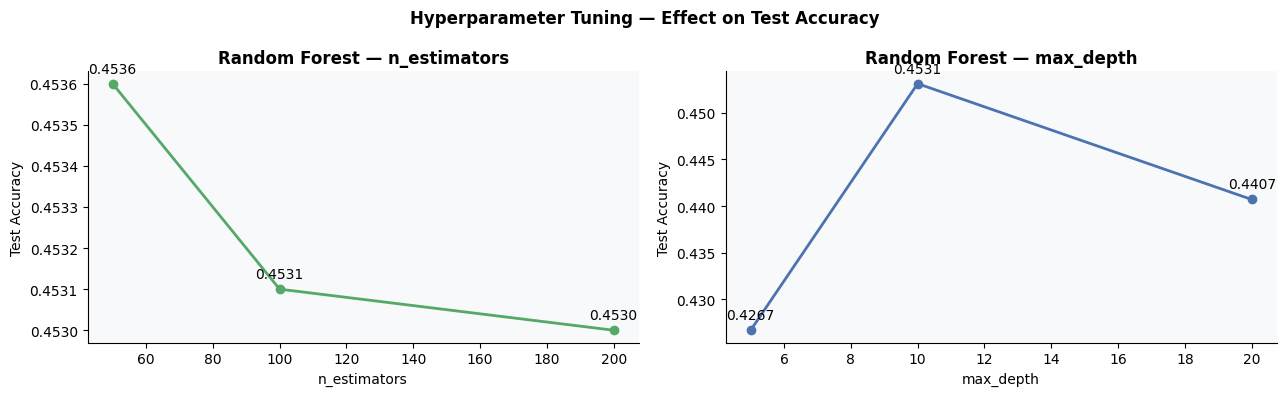

In [ ]:
hp_data = {
    'Random Forest — n_estimators': ([50, 100, 200],  [0.4536, 0.4531, 0.4530], '#55A868'),
    'Random Forest — max_depth':    ([5,  10,  20],   [0.4267, 0.4531, 0.4407], '#4C72B0'),
}

fig, axes = plt.subplots(1, len(hp_data), figsize=(13, 4))
fig.suptitle('Hyperparameter Tuning — Effect on Test Accuracy', fontweight='bold')

for ax, (title, (xs, ys, color)) in zip(axes, hp_data.items()):
    ax.plot(xs, ys, marker='o', color=color, linewidth=2)
    for x, y in zip(xs, ys):
        ax.annotate(f'{y:.4f}', (x, y), xytext=(0, 8), textcoords='offset points', ha='center')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title.split('— ')[1])
    ax.set_ylabel('Test Accuracy')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

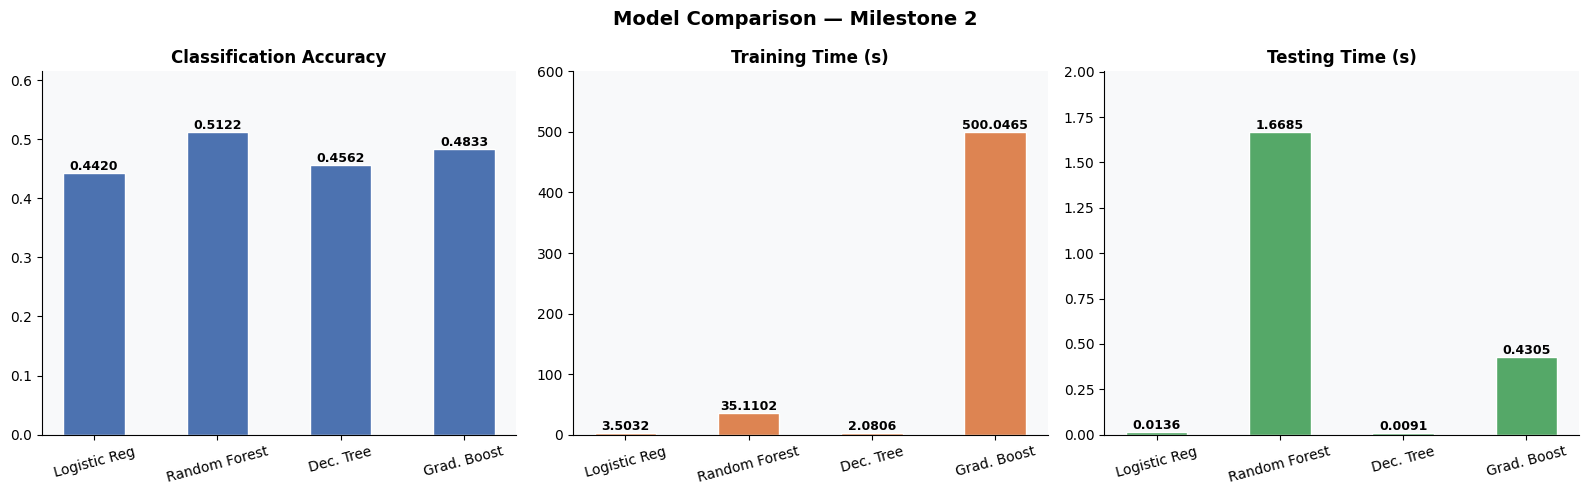

In [ ]:
accs = [best_tracker[k]['test_acc']   for k in KEYS]
trnt = [best_tracker[k]['train_time'] for k in KEYS]
tstt = [best_tracker[k]['test_time']  for k in KEYS]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Milestone 2', fontsize=14, fontweight='bold')

for ax, vals, title, color in zip(
    axes,
    [accs, trnt, tstt],
    ['Classification Accuracy', 'Training Time (s)', 'Testing Time (s)'],
    ['#4C72B0', '#DD8452', '#55A868']
):
    bars = ax.bar(NAMES, vals, color=color, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.2)

plt.tight_layout()
plt.savefig('bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

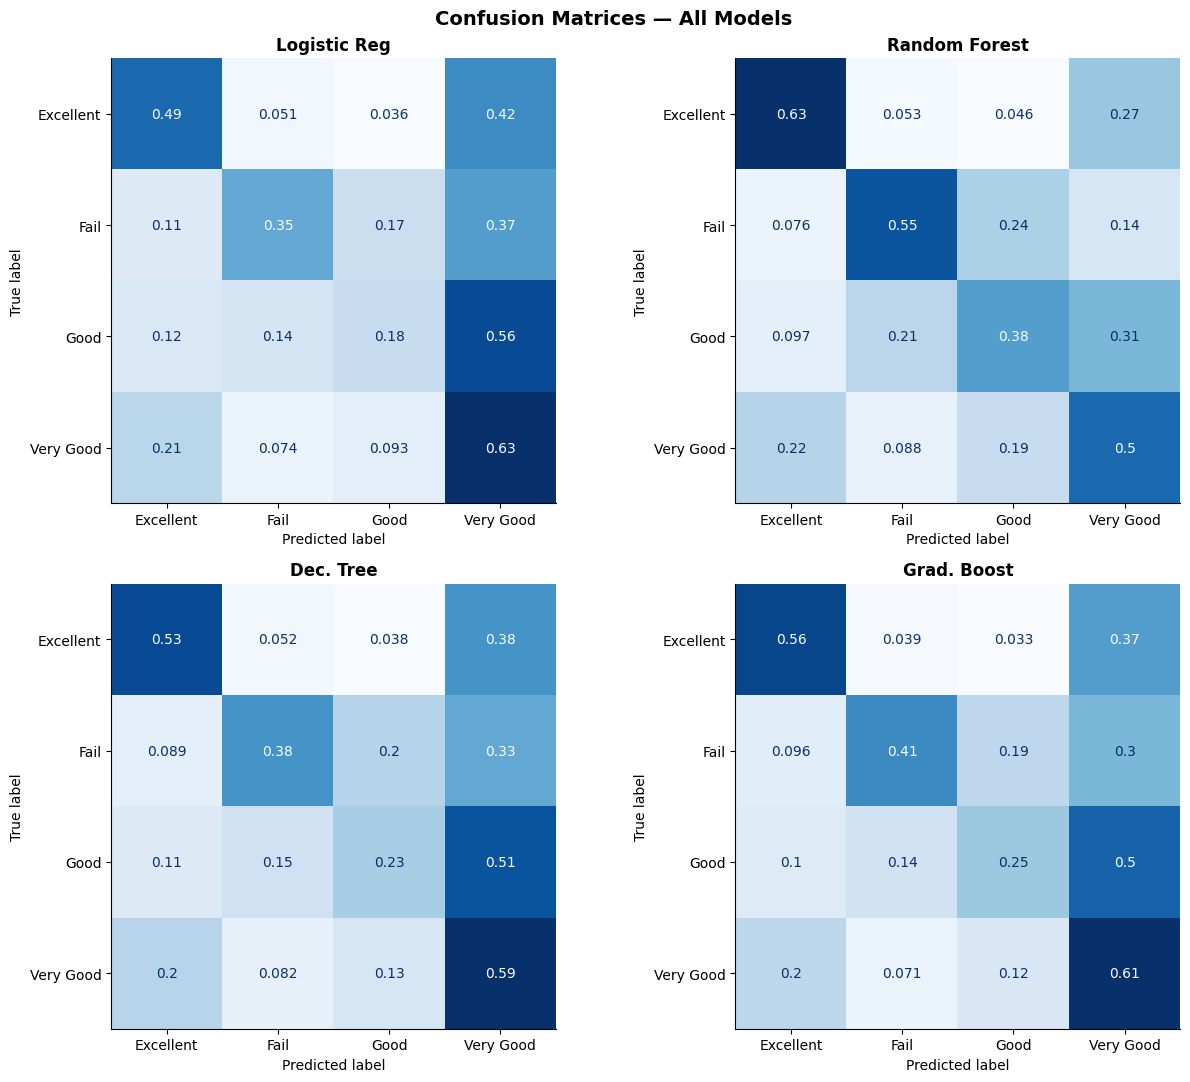

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, key, name in zip(axes.flatten(), KEYS, NAMES):
    y_pred = best_tracker[key]['model'].predict(scaler.transform(X_test_raw))
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
rows = []
for key, name in zip(KEYS, NAMES):
    y_pred = best_tracker[key]['model'].predict(X_test)
    print(f"\n{'─'*50}\n{name}\n{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=CLASSES))
    rows.append({
        'Model':      name,
        'Train Acc':  f"{best_tracker[key]['train_acc']:.4f}",
        'Test Acc':   f"{best_tracker[key]['test_acc']:.4f}",
        'Macro F1':   f"{f1_score(y_test, y_pred, average='macro'):.4f}",
        'Train Time': f"{best_tracker[key]['train_time']:.2f}s",
        'Test Time':  f"{best_tracker[key]['test_time']:.4f}s",
    })

display(pd.DataFrame(rows).set_index('Model'))


──────────────────────────────────────────────────
Logistic Reg
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Excellent       0.51      0.49      0.50      8271
        Fail       0.44      0.35      0.39      5260
        Good       0.38      0.18      0.24      7727
   Very Good       0.42      0.63      0.51     11525

    accuracy                           0.44     32783
   macro avg       0.44      0.41      0.41     32783
weighted avg       0.44      0.44      0.42     32783


──────────────────────────────────────────────────
Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Excellent       0.58      0.63      0.61      8271
        Fail       0.48      0.55      0.51      5260
        Good       0.43      0.38      0.40      7727
   Very Good       0.52      0.50      0.51     11525

    accuracy                           0.51     32783
   mac

,Train Acc,Test Acc,Macro F1,Train Time,Test Time
Model,,,,,
Logistic Reg,0.4419,0.4420,0.4086,3.50s,0.0136s
Random Forest,0.9061,0.5122,0.5081,35.11s,1.6685s
Dec. Tree,0.4863,0.4562,0.4336,2.08s,0.0091s
Grad. Boost,0.5039,0.4833,0.4627,500.05s,0.4305s


# Test Script

In [ ]:
def build_classification_test_dataframe(test_path):
    assessments = pd.read_csv(test_path + "assessments.csv")
    courses = pd.read_csv(test_path + "courses.csv")
    studentAssessment = pd.read_csv(test_path + "StudentAssesments.csv")
    studentInfo = pd.read_csv(test_path + "studentInfo.csv")
    studentRegistration = pd.read_csv(test_path + "studentRegistration.csv")
    studentVle = pd.read_csv(test_path + "studentVle.csv")
    vle = pd.read_csv(test_path + "vle.csv")

    studentVle_full = studentVle.merge(
        vle,
        on=["id_site", "code_module", "code_presentation"]
    )

    studentVle_agg = studentVle_full.groupby(
        ["code_module", "code_presentation", "id_student"]
    ).agg(
        total_clicks=("sum_click", "sum"),
        avg_clicks=("sum_click", "mean"),
        interaction_days=("date", "nunique"),
        total_interactions=("id_site", "count"),
        unique_activity_types=("activity_type", "nunique")
    ).reset_index()

    df = studentAssessment.merge(
        assessments,
        on="id_assessment",
        how="left"
    )

    df = df.merge(
        studentInfo,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        courses,
        on=["code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        studentRegistration,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    df = df.merge(
        studentVle_agg,
        on=["id_student", "code_module", "code_presentation"],
        how="left"
    )

    return df

In [ ]:
def preprocess_classification_unseen(test_df):
    test_df = test_df.copy()

    test_df.replace("?", np.nan, inplace=True)

    y_true = None
    if "assessmentClass" in test_df.columns:
        y_true = test_df["assessmentClass"].copy()
        test_df.drop(columns=["assessmentClass"], inplace=True)

    if "date_unregistration" in test_df.columns:
        test_df["has_unregistered"] = test_df["date_unregistration"].notna().astype(int)
    else:
        test_df["has_unregistered"] = 0

    drop_cols = ["id_assessment", "id_student", "date_unregistration"]
    test_df.drop(columns=[c for c in drop_cols if c in test_df.columns], inplace=True)

    for c in ["date", "date_registration"]:
        if c in test_df.columns:
            test_df[c] = pd.to_numeric(test_df[c], errors="coerce")
        else:
            test_df[c] = np.nan

    test_df["date"] = test_df["date"].fillna(classification_preprocess_values["date_median"])
    test_df["date_registration"] = test_df["date_registration"].fillna(
        classification_preprocess_values["date_registration_median"]
    )

    if "imd_band" in test_df.columns:
        test_df["imd_band"] = test_df["imd_band"].fillna("Unknown")

    vle_cols = [
        "total_clicks",
        "avg_clicks",
        "interaction_days",
        "total_interactions",
        "unique_activity_types"
    ]

    for c in vle_cols:
        if c in test_df.columns:
            test_df[c] = test_df[c].fillna(0)
        else:
            test_df[c] = 0

    cat_cols = test_df.select_dtypes(include="object").columns.tolist()
    test_df = pd.get_dummies(test_df, columns=cat_cols)

    test_df["submission_offset"] = test_df["date_submitted"] - test_df["date"]
    test_df["submitted_late"] = (test_df["submission_offset"] > 0).astype(int)
    test_df["submitted_early"] = (test_df["submission_offset"] < -3).astype(int)
    test_df["submission_timing_ratio"] = test_df["submission_offset"] / (
        test_df["module_presentation_length"] + 1
    )

    test_df["click_per_day"] = test_df["total_clicks"] / (test_df["interaction_days"] + 1)
    test_df["avg_clicks_per_interaction"] = test_df["total_clicks"] / (
        test_df["total_interactions"] + 1
    )
    test_df["activity_diversity_ratio"] = test_df["unique_activity_types"] / (
        test_df["total_interactions"] + 1
    )
    test_df["engagement_ratio"] = (
        test_df["interaction_days"] / (test_df["module_presentation_length"] + 1)
    ).clip(upper=1.0)

    test_df["is_heavy_engager"] = (
        test_df["total_clicks"] >= classification_preprocess_values["click_threshold"]
    ).astype(int)

    test_df["registration_offset"] = test_df["date_registration"]
    test_df["has_prior_attempts"] = (test_df["num_of_prev_attempts"] > 0).astype(int)
    test_df["high_credit_load"] = (
        test_df["studied_credits"] > classification_preprocess_values["studied_credits_median"]
    ).astype(int)

    test_df["engaged_but_late"] = (
        (test_df["is_heavy_engager"] == 1) & (test_df["submitted_late"] == 1)
    ).astype(int)

    test_df["low_engagement_late"] = (
        (test_df["is_heavy_engager"] == 0) & (test_df["submitted_late"] == 1)
    ).astype(int)

    test_df.drop(
        columns=[c for c in ["avg_clicks", "total_interactions", "interaction_days"] if c in test_df.columns],
        inplace=True
    )

    test_df = test_df.reindex(columns=feature_columns, fill_value=0)

    test_df = test_df.fillna(0)

    return test_df, y_true

In [ ]:
# Load saved classification objects
classification_model = pickle.load(open(save_dir + "rf_model.pkl", "rb"))  # change rf if another model is best
classification_scaler = pickle.load(open(save_dir + "classification_scaler.pkl", "rb"))
target_le = pickle.load(open(save_dir + "target_le.pkl", "rb"))
feature_columns = pickle.load(open(save_dir + "classification_feature_columns.pkl", "rb"))
classification_preprocess_values = pickle.load(open(save_dir + "classification_preprocess_values.pkl", "rb"))

print("Loaded classification model and preprocessing objects.")

Loaded classification model and preprocessing objects.


In [ ]:
# ============================================================
# PRACTICAL TEST CODE - DO NOT RUN NOW
# Run this only tomorrow when the TA gives you the unseen 7 CSV files.
# Change test_path to the folder containing the 7 unseen CSV files.
# ============================================================

# test_path = "/content/drive/MyDrive/MS2 ML Project/unseen_test/"

# # 1. Build merged dataframe from the 7 unseen CSVs
# test_df = build_classification_test_dataframe(test_path)

# # 2. Apply same preprocessing as training
# X_unseen_raw, y_true = preprocess_classification_unseen(test_df)

# # 3. Scale using saved scaler
# X_unseen_scaled = classification_scaler.transform(X_unseen_raw)

# # 4. Predict using saved model
# pred_numeric = classification_model.predict(X_unseen_scaled)
# pred_labels = target_le.inverse_transform(pred_numeric)

# # 5. Show predictions
# classification_results = pd.DataFrame({
#     "prediction_code": pred_numeric,
#     "prediction_label": pred_labels
# })

# print(classification_results.head())
# print("\nPrediction distribution:")
# print(classification_results["prediction_label"].value_counts())

# # 6. If target exists in unseen files, show accuracy and report
# if y_true is not None:
#     y_true_encoded = target_le.transform(y_true)

#     print("Classification Accuracy:", accuracy_score(y_true_encoded, pred_numeric))
#     print("\nClassification Report:")
#     print(classification_report(
#         y_true_encoded,
#         pred_numeric,
#         target_names=target_le.classes_
#     ))
# else:
#     print("No assessmentClass column found in unseen test data, so only predictions were generated.")

In [ ]:
import os

expected_files = [
    "lr_model.pkl",
    "rf_model.pkl",
    "dt_model.pkl",
    "gb_model.pkl",
    "classification_scaler.pkl",
    "target_le.pkl",
    "classification_feature_columns.pkl",
    "classification_preprocess_values.pkl"
]

for file in expected_files:
    full_path = save_dir + file
    print(file, "FOUND" if os.path.exists(full_path) else "MISSING")

lr_model.pkl FOUND
rf_model.pkl FOUND
dt_model.pkl FOUND
gb_model.pkl FOUND
classification_scaler.pkl FOUND
target_le.pkl FOUND
classification_feature_columns.pkl FOUND
classification_preprocess_values.pkl FOUND


In [ ]:
# Check 2: load saved objects

loaded_model = pickle.load(open(save_dir + "rf_model.pkl", "rb"))
loaded_scaler = pickle.load(open(save_dir + "classification_scaler.pkl", "rb"))
loaded_target_le = pickle.load(open(save_dir + "target_le.pkl", "rb"))
loaded_feature_columns = pickle.load(open(save_dir + "classification_feature_columns.pkl", "rb"))
loaded_preprocess_values = pickle.load(open(save_dir + "classification_preprocess_values.pkl", "rb"))

print("Model loaded:", type(loaded_model))
print("Scaler loaded:", type(loaded_scaler))
print("Target classes:", loaded_target_le.classes_)
print("Number of feature columns:", len(loaded_feature_columns))
print("Preprocessing values:", loaded_preprocess_values)

Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>
Target classes: ['Excellent' 'Fail' 'Good' 'Very Good']
Number of feature columns: 75
Preprocessing values: {'date_median': 129.0, 'date_registration_median': -53.0, 'click_threshold': np.float64(2695.0), 'studied_credits_median': 60.0}


In [ ]:
# Check 3: test saved model on the internal 20% test split

X_check = X_test_raw.copy()
X_check = X_check.reindex(columns=loaded_feature_columns, fill_value=0)

X_check_scaled = loaded_scaler.transform(X_check)

pred_check = loaded_model.predict(X_check_scaled)
pred_labels_check = loaded_target_le.inverse_transform(pred_check)

print("Predictions shape:", pred_check.shape)
print("First 10 prediction codes:", pred_check[:10])
print("First 10 prediction labels:", pred_labels_check[:10])

print("\nAccuracy using loaded model:")
print(accuracy_score(y_test, pred_check))

Predictions shape: (32783,)
First 10 prediction codes: [1 0 2 2 2 0 2 3 0 1]
First 10 prediction labels: ['Fail' 'Excellent' 'Good' 'Good' 'Good' 'Excellent' 'Good' 'Very Good'
 'Excellent' 'Fail']

Accuracy using loaded model:
0.5122472012933532
